# Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    torch.cuda.manual_seed(42)

Using device: cuda
GPU: Tesla T4
CUDA version: 12.4


# Data Preprocessor

In [2]:
class DataPreprocessor:
    def __init__(self, data_path, img_size=224, batch_size=32):
        self.data_path = data_path
        self.img_size = img_size
        self.batch_size = batch_size
        self.class_weights = None
    
    def get_transforms(self):
        train_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        val_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        return train_transforms, val_transforms
    
    def compute_class_weights(self, dataset):
        class_counts = {}
        for _, label in dataset:
            class_counts[label] = class_counts.get(label, 0) + 1
        
        total_samples = len(dataset)
        num_classes = len(class_counts)
        weights = []
        
        for i in range(num_classes):
            class_samples = class_counts[i]
            weight = total_samples / (num_classes * class_samples)
            weights.append(weight)
        
        self.class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
        print(f"Class weights computed: {weights}")
        return self.class_weights
    
    def prepare_datasets(self):
        train_transforms, val_transforms = self.get_transforms()
        
        full_dataset = datasets.ImageFolder(
            root=self.data_path,
            transform=train_transforms
        )
        
        self.class_names = full_dataset.classes
        print(f"Dataset classes: {self.class_names}")
        print(f"Total samples: {len(full_dataset)}")
        
        # Split dataset (70% train, 15% validation, 15% test)
        train_size = int(0.7 * len(full_dataset))
        val_size = int(0.15 * len(full_dataset))
        test_size = len(full_dataset) - train_size - val_size
        
        train_dataset, val_test_dataset = random_split(
            full_dataset, [train_size, val_size + test_size]
        )
        
        val_dataset, test_dataset = random_split(
            val_test_dataset, [val_size, test_size]
        )
        
        # Apply validation transforms
        val_dataset.dataset.transform = val_transforms
        test_dataset.dataset.transform = val_transforms
        
        print(f"Training samples: {len(train_dataset)}")
        print(f"Validation samples: {len(val_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        self.compute_class_weights(train_dataset)
        
        return train_dataset, val_dataset, test_dataset
    
    def prepare_dataloaders(self):
        train_dataset, val_dataset, test_dataset = self.prepare_datasets()
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=True if device.type == 'cuda' else False
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True if device.type == 'cuda' else False
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True if device.type == 'cuda' else False
        )
        
        return train_loader, val_loader, test_loader

# Model Architecture

In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual
        out = self.relu(out)
        return out

class CustomPlantCNN(nn.Module):
    def __init__(self, num_classes=16, dropout_rate=0.5):
        super(CustomPlantCNN, self).__init__()
        
        # Initial Convolutional Layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Residual Blocks
        self.layer1 = self._make_layer(32, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(512, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)
        
        # Initialize weights
        self._initialize_weights()
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

#  Trainer

In [4]:
class PlantTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, scheduler, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.learning_rates = []
    
    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc="Training")
        for data, targets in pbar:
            data, targets = data.to(self.device), targets.to(self.device)
            
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def validate_epoch(self):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, targets in self.val_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                outputs = self.model(data)
                loss = self.criterion(outputs, targets)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc
    
    def train(self, epochs, patience=10):
        best_val_acc = 0
        patience_counter = 0
        start_time = time.time()
        
        print("Starting training...")
        
        for epoch in range(epochs):
            print(f'\nEpoch {epoch+1}/{epochs}')
            print('-' * 50)
            
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch()
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            self.learning_rates.append(self.optimizer.param_groups[0]['lr'])
            
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            print(f'Learning Rate: {self.learning_rates[-1]:.6f}')
            
            self.scheduler.step(val_acc)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_cnn.pth')
                print(f'New best model saved! Validation Accuracy: {val_acc:.2f}%')
            else:
                patience_counter += 1
                print(f'Early stopping counter: {patience_counter}/{patience}')
            
            if patience_counter >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs!')
                break
        
        training_time = time.time() - start_time
        print(f'\nTraining completed in {training_time:.2f} seconds')
        print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
        return training_time, best_val_acc

#  Model Evaluator 

In [5]:
class ModelEvaluator:
    def __init__(self, model, test_loader, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.class_names = class_names
    
    def evaluate_model(self):
        self.model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        test_correct = 0
        test_total = 0
        
        start_time = time.time()
        with torch.no_grad():
            for data, targets in tqdm(self.test_loader, desc='Testing'):
                data, targets = data.to(self.device), targets.to(self.device)
                outputs = self.model(data)
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
                test_total += targets.size(0)
                test_correct += predicted.eq(targets).sum().item()
        
        inference_time = time.time() - start_time
        accuracy = 100. * test_correct / test_total
        
        all_predictions = np.array(all_predictions)
        all_targets = np.array(all_targets)
        all_probabilities = np.array(all_probabilities)
        
        print(f'\nTest Accuracy: {accuracy:.2f}%')
        print(f'Inference Time: {inference_time:.2f} seconds')
        return all_predictions, all_targets, all_probabilities, accuracy, inference_time
    
    def plot_confusion_matrix(self, predictions, targets):
        cm = confusion_matrix(targets, predictions)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names,
                    yticklabels=self.class_names)
        plt.title('Confusion Matrix - Custom CNN')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        return cm
    
    def plot_roc_auc(self, targets, probabilities, n_classes=16):
        # Binarize the output
        y_test_bin = label_binarize(targets, classes=range(n_classes))
        
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probabilities[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), probabilities.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        
        # Plot ROC curves
        plt.figure(figsize=(12, 10))
        
        # Plot micro-average ROC curve
        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average ROC curve (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=4)
        
        # Plot ROC curves for each class
        colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'Class {self.class_names[i]} (AUC = {roc_auc[i]:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves for Multi-Class Classification')
        plt.legend(loc="lower right", bbox_to_anchor=(1.5, 0.5))
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Compute macro-average ROC AUC
        all_roc_auc = [roc_auc[i] for i in range(n_classes)]
        macro_auc = np.mean(all_roc_auc)
        print(f'Macro-average ROC AUC: {macro_auc:.4f}')
        print(f'Micro-average ROC AUC: {roc_auc["micro"]:.4f}')
        
        return roc_auc

# Main Configuration and Execution

In [6]:
# Configuration
DATA_PATH = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 10

print("Custom CNN Model for Medicinal Plants Classification")
print("=" * 60)

# Data Preparation
print("\n1. Preparing Data with Class Weights...")
preprocessor = DataPreprocessor(DATA_PATH, IMG_SIZE, BATCH_SIZE)
train_loader, val_loader, test_loader = preprocessor.prepare_dataloaders()
class_names = preprocessor.class_names
class_weights = preprocessor.class_weights

Custom CNN Model for Medicinal Plants Classification

1. Preparing Data with Class Weights...
Dataset classes: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']
Total samples: 3494
Training samples: 2445
Validation samples: 524
Test samples: 525
Class weights computed: [1.115419708029197, 1.232358870967742, 0.5361842105263158, 1.4553571428571428, 1.3523230088495575, 1.3643973214285714, 1.7564655172413792, 0.992288961038961, 1.4281542056074767, 0.800065445026178, 0.7042050691244239, 1.543560606060606, 0.7756979695431472, 0.800065445026178, 0.9375, 0.9375]


# Model Initialization

In [7]:
# Initialize Model
print("\n2. Initializing Custom CNN with Residual Connections...")
model = CustomPlantCNN(num_classes=len(class_names), dropout_rate=0.5)
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized with {total_params:,} total parameters")
print(f"Trainable parameters: {trainable_params:,}")


2. Initializing Custom CNN with Residual Connections...
Model initialized with 11,426,352 total parameters
Trainable parameters: 11,426,352


#  Training Setup

In [8]:
# Training Setup with Class Weighted Loss
print("\n3. Setting up Training with Class Weighted Loss...")
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training
print("\n4. Starting Training...")
trainer = PlantTrainer(model, train_loader, val_loader, criterion, optimizer, scheduler, device)
training_time, best_val_acc = trainer.train(EPOCHS, PATIENCE)


3. Setting up Training with Class Weighted Loss...

4. Starting Training...
Starting training...

Epoch 1/100
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:12<00:00,  6.25it/s, Loss=1.8640, Acc=38.24%]


Train Loss: 1.8167, Train Acc: 38.24%
Val Loss: 2.8341, Val Acc: 23.09%
Learning Rate: 0.001000
New best model saved! Validation Accuracy: 23.09%

Epoch 2/100
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:10<00:00,  7.05it/s, Loss=1.1050, Acc=56.77%]


Train Loss: 1.2297, Train Acc: 56.77%
Val Loss: 1.4349, Val Acc: 48.85%
Learning Rate: 0.001000
New best model saved! Validation Accuracy: 48.85%

Epoch 3/100
--------------------------------------------------


...

Train Loss: 0.0193, Train Acc: 99.43%
Val Loss: 0.0354, Val Acc: 98.85%
Learning Rate: 0.000063
Early stopping counter: 8/10

Epoch 51/100
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:11<00:00,  6.99it/s, Loss=0.4543, Acc=99.35%]


Train Loss: 0.0261, Train Acc: 99.35%
Val Loss: 0.0465, Val Acc: 98.66%
Learning Rate: 0.000063
Early stopping counter: 9/10

Epoch 52/100
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:11<00:00,  6.72it/s, Loss=0.4458, Acc=99.35%]


Train Loss: 0.0263, Train Acc: 99.35%
Val Loss: 0.0363, Val Acc: 99.05%
Learning Rate: 0.000063
Early stopping counter: 10/10
Early stopping triggered after 52 epochs!

Training completed in 706.27 seconds
Best Validation Accuracy: 99.24%


# Model Evaluation

In [9]:
# Load Best Model and Evaluate
print("\n5. Loading Best Model and Evaluating...")
model.load_state_dict(torch.load('best_cnn.pth'))
evaluator = ModelEvaluator(model, test_loader, device, class_names)
predictions, targets, probabilities, test_accuracy, inference_time = evaluator.evaluate_model()


5. Loading Best Model and Evaluating...


Testing: 100%|██████████| 17/17 [00:03<00:00,  5.51it/s]


Test Accuracy: 97.90%
Inference Time: 3.09 seconds


# Confusion Matrix


6. Generating Confusion Matrix...


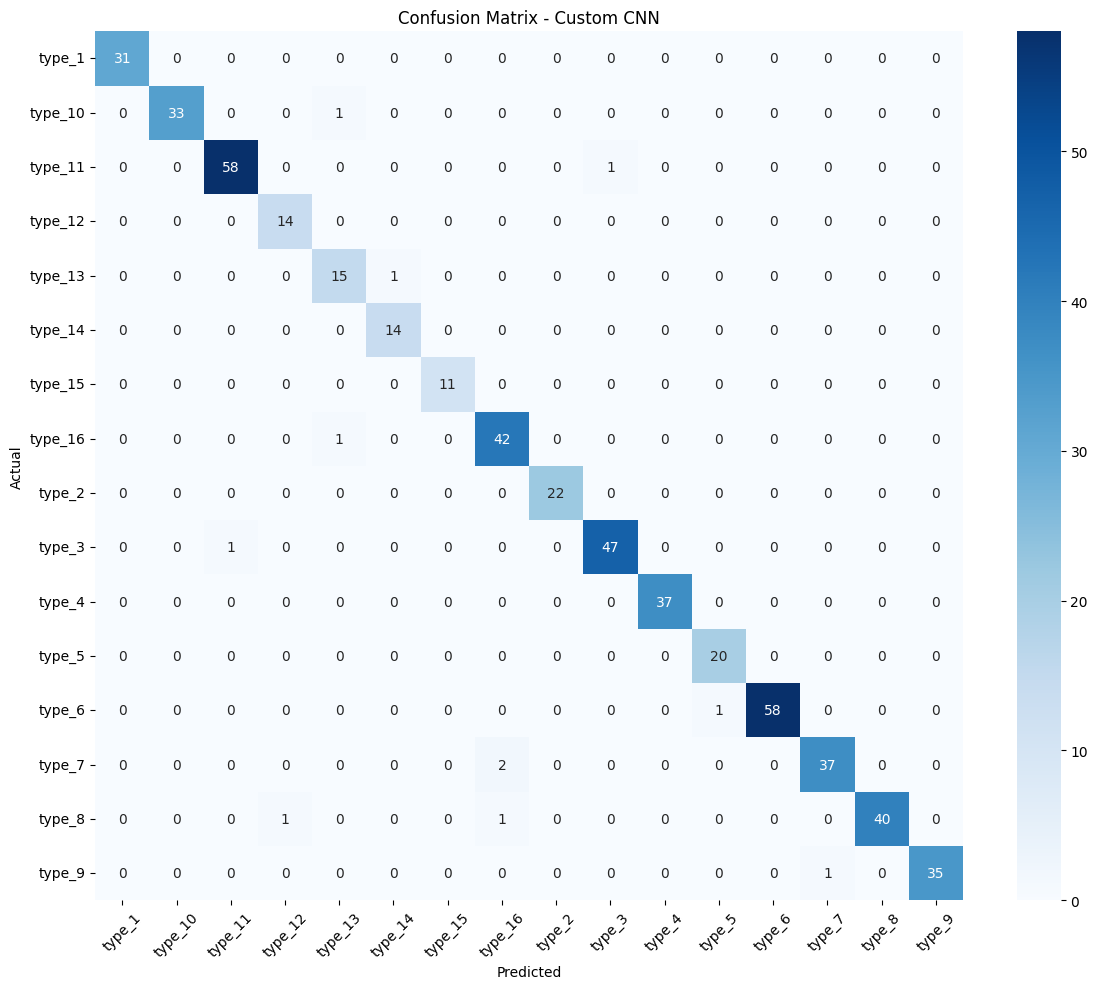

In [10]:
#  Confusion Matrix
print("\n6. Generating Confusion Matrix...")
cm = evaluator.plot_confusion_matrix(predictions, targets)

# ROC/AUC Plot


7. Generating ROC/AUC Curves...


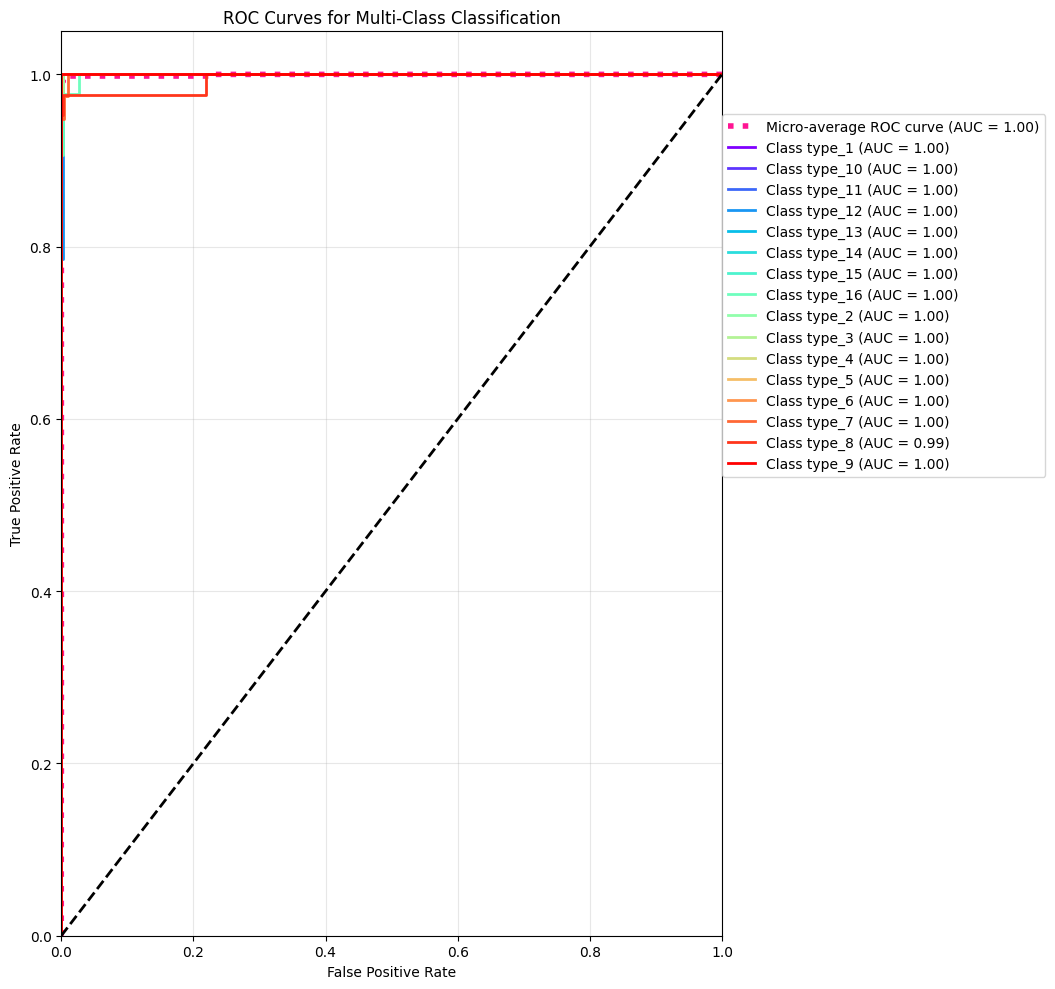

Macro-average ROC AUC: 0.9996
Micro-average ROC AUC: 0.9994


In [11]:
# ROC/AUC Curves
print("\n7. Generating ROC/AUC Curves...")
roc_auc = evaluator.plot_roc_auc(targets, probabilities, n_classes=len(class_names))

# Classification Report

In [12]:
# Classification Report
print("\n8. Generating Classification Report...")
report = classification_report(targets, predictions, target_names=class_names)
print(report)


8. Generating Classification Report...
              precision    recall  f1-score   support

      type_1       1.00      1.00      1.00        31
     type_10       1.00      0.97      0.99        34
     type_11       0.98      0.98      0.98        59
     type_12       0.93      1.00      0.97        14
     type_13       0.88      0.94      0.91        16
     type_14       0.93      1.00      0.97        14
     type_15       1.00      1.00      1.00        11
     type_16       0.93      0.98      0.95        43
      type_2       1.00      1.00      1.00        22
      type_3       0.98      0.98      0.98        48
      type_4       1.00      1.00      1.00        37
      type_5       0.95      1.00      0.98        20
      type_6       1.00      0.98      0.99        59
      type_7       0.97      0.95      0.96        39
      type_8       1.00      0.95      0.98        42
      type_9       1.00      0.97      0.99        36

    accuracy                           0

#  Training History Plots


9. Plotting Training History...


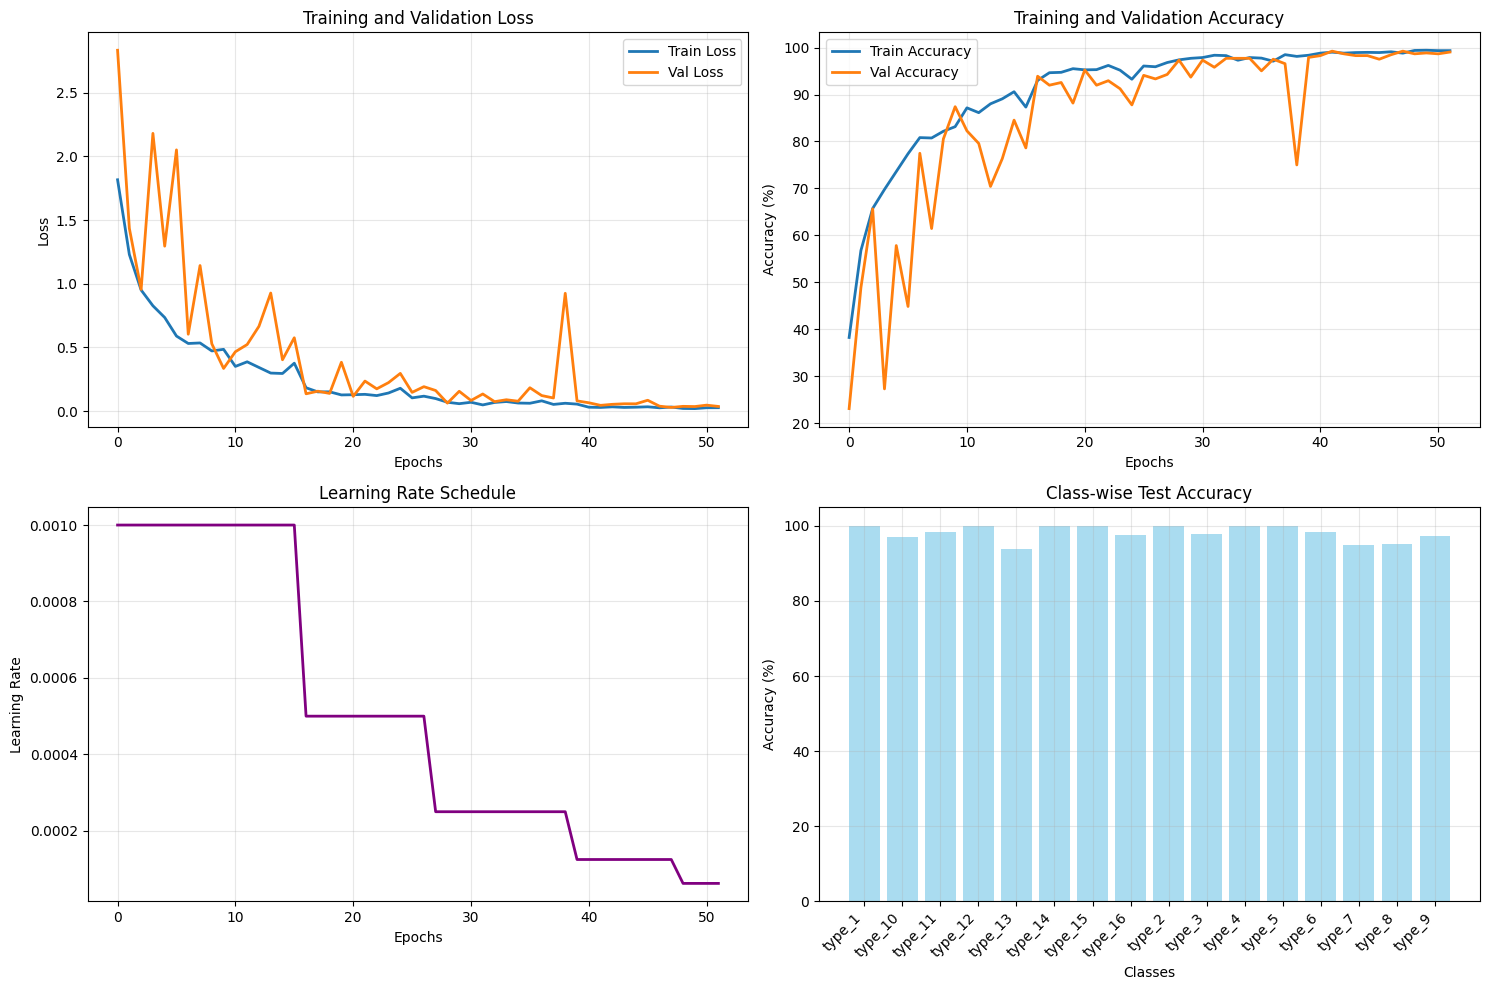

In [13]:
# Plot Training History
print("\n9. Plotting Training History...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss plot
axes[0, 0].plot(trainer.train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(trainer.val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plot
axes[0, 1].plot(trainer.train_accuracies, label='Train Accuracy', linewidth=2)
axes[0, 1].plot(trainer.val_accuracies, label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate plot
axes[1, 0].plot(trainer.learning_rates, color='purple', linewidth=2)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True, alpha=0.3)

# Class-wise accuracy
class_accuracies = []
for i, class_name in enumerate(class_names):
    class_mask = targets == i
    if np.sum(class_mask) > 0:
        class_acc = np.mean(predictions[class_mask] == i) * 100
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

axes[1, 1].bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.7)
axes[1, 1].set_xlabel('Classes')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Class-wise Test Accuracy')
axes[1, 1].set_xticks(range(len(class_names)))
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Final Summary

In [14]:
# Final Summary
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY - CUSTOM CNN MODEL")
print("=" * 60)
print(f"Input Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Inference Time: {inference_time:.2f} seconds")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Best Model Saved: best_cnn.pth")

# Save results
results_df = pd.DataFrame({
    'Input_Size': [f'{IMG_SIZE}x{IMG_SIZE}'],
    'Training_Time_s': [training_time],
    'Inference_Time_s': [inference_time],
    'Best_Val_Acc': [best_val_acc],
    'Test_Acc': [test_accuracy],
    'Parameters': [total_params],
    'Trainable_Parameters': [trainable_params],
    'Batch_Size': [BATCH_SIZE],
    'Learning_Rate': [LEARNING_RATE]
})
results_df.to_csv('cnn_results.csv', index=False)
print("\nResults saved to 'cnn_results.csv'")


FINAL RESULTS SUMMARY - CUSTOM CNN MODEL
Input Size: 224x224
Training Time: 706.27 seconds
Inference Time: 3.09 seconds
Best Validation Accuracy: 99.24%
Test Accuracy: 97.90%
Total Parameters: 11,426,352
Trainable Parameters: 11,426,352
Best Model Saved: best_cnn.pth

Results saved to 'cnn_results.csv'
